In [2]:
pip install pandas numpy matplotlib seaborn plotly

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# LOading Dataset

In [32]:
file_path = "/content/first inten project.csv"
df = pd.read_csv(file_path)

# 1. Data Preprocessing

In [33]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [34]:
print(df.dtypes)  #COLUMNS NAME & THEIR DATA TYPES

Booking_ID                   object
number of adults              int64
number of children            int64
number of weekend nights      int64
number of week nights         int64
type of meal                 object
car parking space             int64
room type                    object
lead time                     int64
market segment type          object
repeated                      int64
P-C                           int64
P-not-C                       int64
average price               float64
special requests              int64
date of reservation          object
booking status               object
dtype: object



Handling Missing Values

In [35]:
#Checking dataset for any missing values
df.isnull().sum()

,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


In [36]:
list(df.columns) #displays original column names in a list


['Booking_ID',
 'number of adults',
 'number of children',
 'number of weekend nights',
 'number of week nights',
 'type of meal',
 'car parking space',
 'room type',
 'lead time',
 'market segment type',
 'repeated',
 'P-C',
 'P-not-C',
 'average price ',
 'special requests',
 'date of reservation',
 'booking status']

 Removing leading or trailing whitespace from the column names

In [37]:
original_columns = list(df.columns)
df.columns = df.columns.str.strip()
modified_columns = [col for col in df.columns if col not in original_columns]

if modified_columns:
    print("Column names with whitespace removed:", modified_columns)
else:
    print("No changes detected in column names.")


Column names with whitespace removed: ['average price']


 Standardizing column names

In [38]:

df.columns = df.columns.str.lower().str.replace(' ', '_')

In [39]:
list(df.columns)

['booking_id',
 'number_of_adults',
 'number_of_children',
 'number_of_weekend_nights',
 'number_of_week_nights',
 'type_of_meal',
 'car_parking_space',
 'room_type',
 'lead_time',
 'market_segment_type',
 'repeated',
 'p-c',
 'p-not-c',
 'average_price',
 'special_requests',
 'date_of_reservation',
 'booking_status']

 Convert date_of_reservation to datetime

In [40]:
df['date_of_reservation'] = pd.to_datetime(df['date_of_reservation'], errors='coerce')
print(df.date_of_reservation)

0       2015-10-02
1       2018-11-06
2       2018-02-28
3       2017-05-20
4       2018-04-11
           ...    
36280   2018-09-13
36281   2017-10-15
36282   2018-12-26
36283   2018-07-06
36284   2018-10-18
Name: date_of_reservation, Length: 36285, dtype: datetime64[ns]


In [41]:
# Drop Booking_ID as it is not useful for modeling
df.drop(columns=['booking_id'], inplace=True)

# 2. Handling Outliers using Log Transformation

In [42]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [43]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low_lim = Q1 - 1.5 * IQR
    up_lim = Q3 + 1.5 * IQR

    print(f"Lower limit for {col}: {low_lim}")
    print(f"Upper limit for {col}: {up_lim}")

    outlier = df[(df[col] > up_lim) | (df[col] < low_lim)][col].tolist()
    outlier = list(set(outlier))
    print(f'Outliers in {col}:', outlier)
    print("\n")

    # Apply log transformation to reduce skewness in outliers
    df[col] = np.log1p(df[col])


Lower limit for number_of_adults: 2.0
Upper limit for number_of_adults: 2.0
Outliers in number_of_adults: [0, 1, 3, 4]


Lower limit for number_of_children: 0.0
Upper limit for number_of_children: 0.0
Outliers in number_of_children: [1, 2, 3, 9, 10]


Lower limit for number_of_weekend_nights: -3.0
Upper limit for number_of_weekend_nights: 5.0
Outliers in number_of_weekend_nights: [6, 7]


Lower limit for number_of_week_nights: -2.0
Upper limit for number_of_week_nights: 6.0
Outliers in number_of_week_nights: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


Lower limit for car_parking_space: 0.0
Upper limit for car_parking_space: 0.0
Outliers in car_parking_space: [1]


Lower limit for lead_time: -146.5
Upper limit for lead_time: 289.5
Outliers in lead_time: [386, 418, 290, 292, 291, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 433, 305, 307, 308, 309, 306, 311, 310, 313, 314, 315, 443, 317, 318, 319, 320, 322, 323, 324, 325, 326, 327, 328, 293, 330, 331, 332, 333, 335, 336, 338, 3

In [44]:
print("Summary statistics after handling outliers:")
print(df[numerical_cols].describe())


Summary statistics after handling outliers:
       number_of_adults  number_of_children  number_of_weekend_nights  \
count      36285.000000        36285.000000              36285.000000   
mean           1.026941            0.063937                  0.480080   
std            0.199466            0.232465                  0.475635   
min            0.000000            0.000000                  0.000000   
25%            1.098612            0.000000                  0.000000   
50%            1.098612            0.000000                  0.693147   
75%            1.098612            0.000000                  1.098612   
max            1.609438            2.397895                  2.079442   

       number_of_week_nights  car_parking_space     lead_time      repeated  \
count           36285.000000       36285.000000  36285.000000  36285.000000   
mean                1.070418           0.021472      3.733556      0.017766   
std                 0.445986           0.120093      1.471985

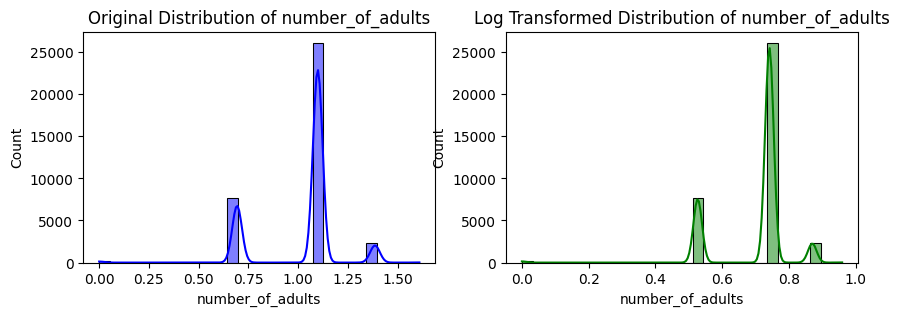

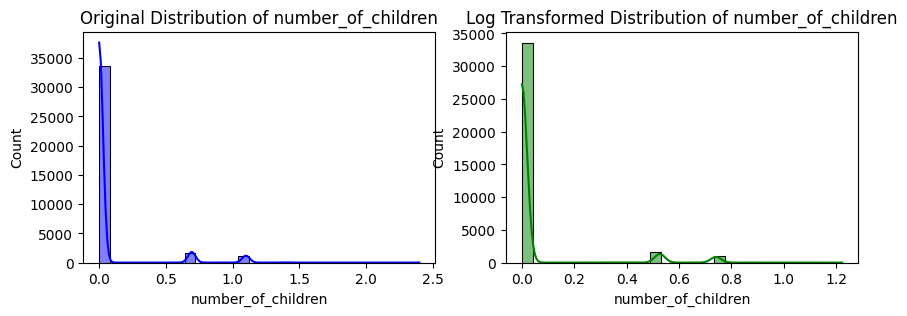

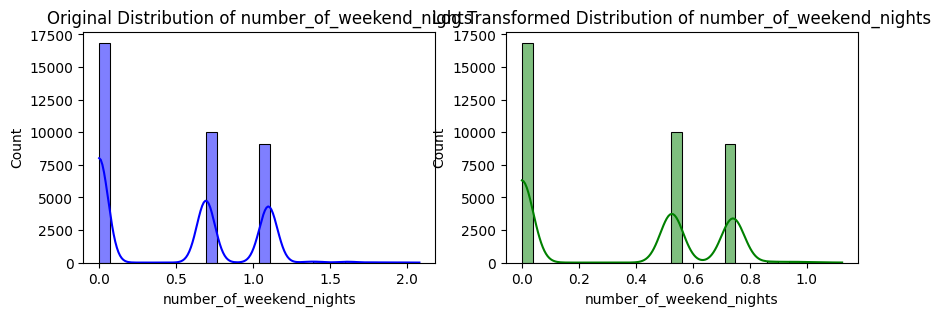

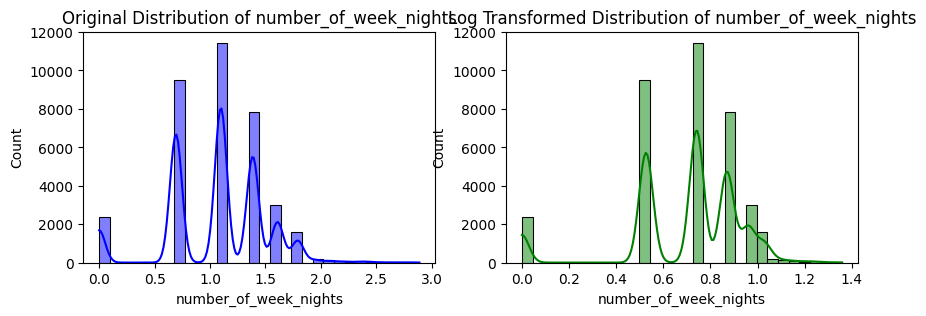

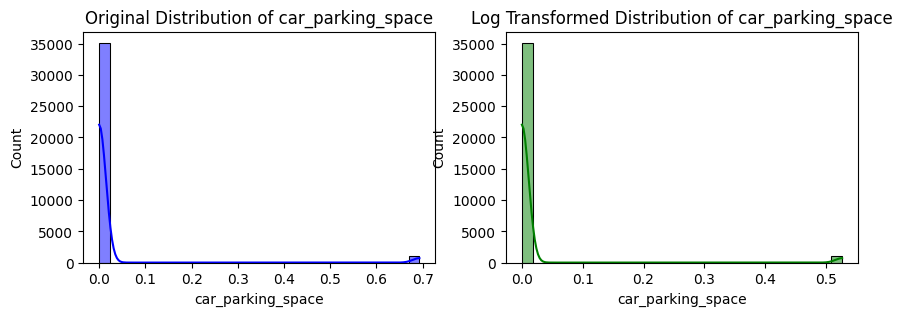

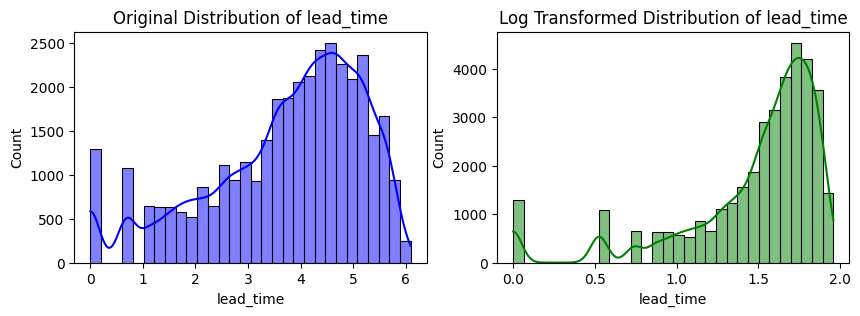

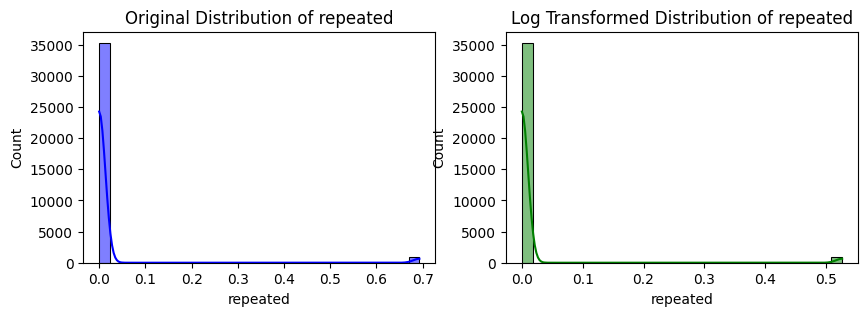

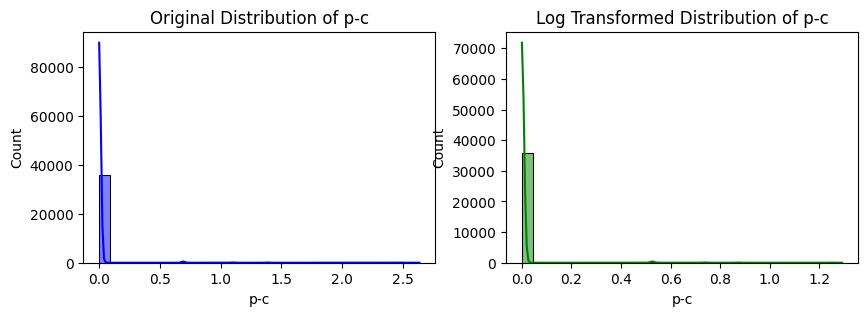

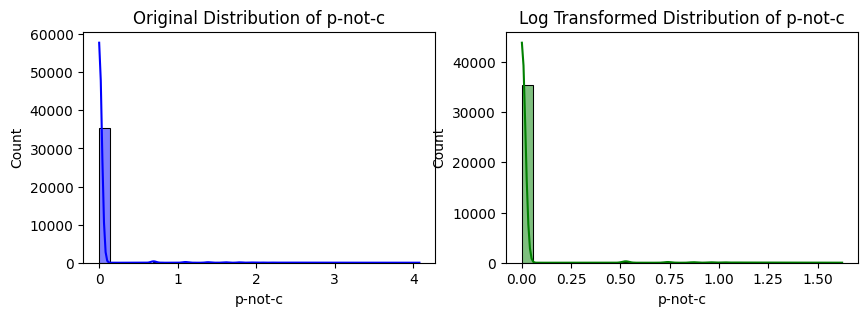

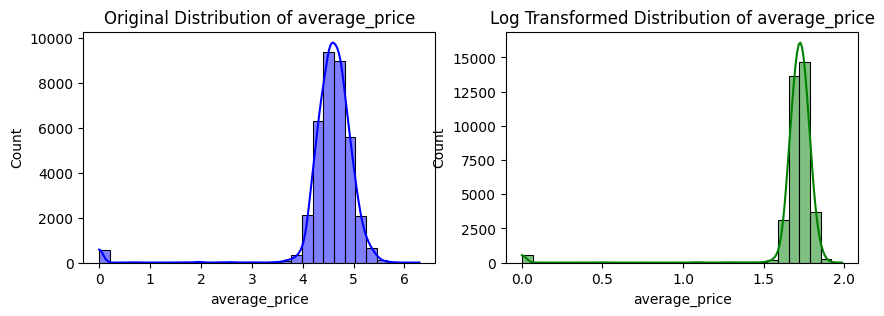

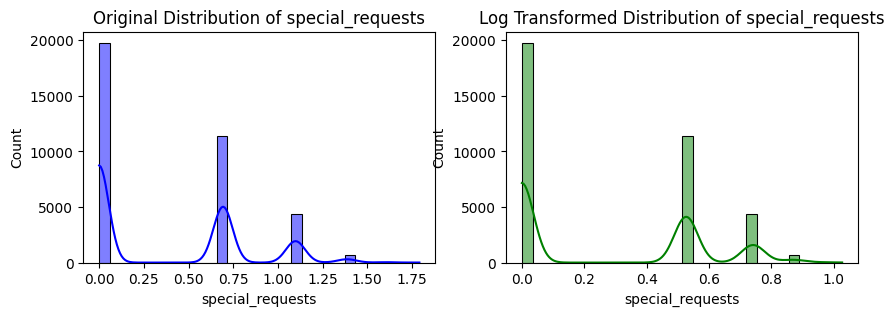

In [45]:
# Visualization Before and After Transformation
for col in numerical_cols:
    plt.figure(figsize=(10, 3))

    # Original Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=30, kde=True, color='blue')
    plt.title(f'Original Distribution of {col}')

    # Transformed Distribution
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df[col]), bins=30, kde=True, color='green')
    plt.title(f'Log Transformed Distribution of {col}')
    plt.show()


# 3. Feature Engineering

In [46]:
# Extract features from date_of_reservation
df['reservation_year'] = df['date_of_reservation'].dt.year
df['reservation_month'] = df['date_of_reservation'].dt.month
df['reservation_day'] = df['date_of_reservation'].dt.day
df.drop(columns=['date_of_reservation'], inplace=True)

In [51]:
# Columns after Feature Extraction
for i in df.columns:
  print(i)

number_of_adults
number_of_children
number_of_weekend_nights
number_of_week_nights
type_of_meal
car_parking_space
room_type
lead_time
market_segment_type
repeated
p-c
p-not-c
average_price
special_requests
booking_status
reservation_year
reservation_month
reservation_day


# 4. Transform Categorical Data

In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
label_enc = LabelEncoder()
df['booking_status'] = label_enc.fit_transform(df['booking_status'])


One-Hot Encoding for categorical variables

In [55]:

categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


# 5. Feature Selection Using Feature Importance (Random Forest)

In [57]:
from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier class

In [58]:
X = df.drop(columns=['booking_status'])
y = df['booking_status']

feature_selector = RandomForestClassifier(n_estimators=100, random_state=42)
feature_selector.fit(X, y)

RandomForestClassifier(random_state=42)

In [60]:
# Get feature importance scores
importances = feature_selector.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [61]:
# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

                              Feature  Importance
5                           lead_time    0.318070
9                       average_price    0.159134
10                   special_requests    0.105737
13                    reservation_day    0.092585
12                  reservation_month    0.080215
3               number_of_week_nights    0.052306
2            number_of_weekend_nights    0.036321
26         market_segment_type_Online    0.028386
11                   reservation_year    0.025530
0                    number_of_adults    0.023986
25        market_segment_type_Offline    0.017582
14           type_of_meal_Meal Plan 2    0.010924
19              room_type_Room_Type 4    0.009206
16          type_of_meal_Not Selected    0.009004
1                  number_of_children    0.007167
4                   car_parking_space    0.006685
24      market_segment_type_Corporate    0.005353
6                            repeated    0.002654
17              room_type_Room_Type 2    0.002532


In [62]:
# We are selecting only important features (e.g., importance > 0.01)
selected_features = feature_importance_df[feature_importance_df['Importance'] > 0.01]['Feature'].tolist()


In [63]:
# Updated X with selected features
X = X[selected_features]


# 6. Train-Test Split

In [65]:
from sklearn.model_selection import train_test_split # Import the train_test_split function

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [67]:
# 7. Modeling & Accuracy Calculation

In [68]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

 Evaluation

In [76]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [77]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'F1-Score: {f1:.2f}')
print(report)


Accuracy: 0.90
F1-Score: 0.93
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      2402
           1       0.91      0.95      0.93      4855

    accuracy                           0.90      7257
   macro avg       0.90      0.88      0.89      7257
weighted avg       0.90      0.90      0.90      7257

